# 01 Generative AI Introduction

## 📚 Learning Objectives

By completing this notebook, you will:
- Define generative AI and typical applications
- Identify model types (GANs, VAEs, LMs) and trade-offs

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 11 "Introduction to Generative AI" — the same map of GANs, VAEs and language models, now that you have trained networks yourself.

**Used later in:** Course 10 (AIAT 124) — Unit 1, which implements every model family named here.

---


## 🎯 "The chatbot is a separate legal entity"

Jake Moffatt's grandmother died in November 2022. On Air Canada's website, its
chatbot told him he could buy a full-price ticket and claim the bereavement
discount back afterwards. That is not Air Canada's policy — bereavement fares must
be requested before purchase — and the airline refused the refund.

Moffatt took it to British Columbia's Civil Resolution Tribunal. Air Canada argued
that its chatbot was "a separate legal entity that is responsible for its own
actions". On **14 February 2024** the tribunal rejected that argument outright: the
chatbot is part of Air Canada's website, the airline is responsible for everything
on it, and it had not taken reasonable care to ensure the information was accurate.
Moffatt was awarded **CAD 812.02** (*Moffatt v. Air Canada*, 2024 BCCRT 149).

Small money, large principle, and a precise technical cause. A generative model
produces the *most plausible continuation* of a conversation. "You can claim the
bereavement fare retroactively" is a highly plausible thing for an airline
assistant to say. Plausibility is what the model optimises; truth is not a term in
its objective function anywhere.

### What goes wrong if you treat a generator like a classifier

A classifier that is wrong hands you a wrong label, and a held-out test set counts
them. A generator that is wrong hands you a **fluent, confident, entirely invented
answer**, formatted exactly like a correct one, with no held-out set that can
count them because there is no single right answer to compare against. That
asymmetry is why every serious generative deployment wraps the model in retrieval,
citation, validation and refusal paths — and why Air Canada lost.


# 01 Generative AI Introduction

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what generative AI is and its importance
- Learn about the evolution of generative AI
- Explore key applications and real-world use cases
- Understand the relationship between generative AI and other AI approaches

## 🔗 Prerequisites

- ✅ Completed Units 1-4
- ✅ Understanding of neural networks
- ✅ Basic Python knowledge

---

## Real-World Context

Generative AI is transforming industries:
- **Content Creation**: AI-generated images, videos, and music
- **Healthcare**: Drug discovery and medical image synthesis
- **Entertainment**: Game asset generation and virtual worlds
- **Business**: Synthetic data generation for training models

This notebook introduces you to the exciting world of generative AI!


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

Example 1: Introduction to Generative AI

1. What is Generative AI?

Generative AI refers to artificial intelligence systems that can create new content, including text, images, audio, video, and other data types.

Key Characteristics:
- Creates NEW content (not just classification or prediction)
- Learns patterns from training data
- Generates novel outputs based on learned patterns
- Can produce diverse and creative outputs


2. Evolution of Generative AI
2014: GANs (Generative Adversarial Networks) introduced
2015: VAEs (Variational Autoencoders) become popular
2017: Transformer architecture revolutionizes NLP
2019: GPT-2 demonstrates impressive text generation
2020: GPT-3 shows few-shot learning capabilities
2021: DALL-E generates images from text
2022: ChatGPT and Stable Diffusion bring generative AI to mainstream
2023: GPT-4 and multimodal models advance the field

3. Key Applications of Generative AI

Text Generation:
  • Creative writing
  • Code generation
  • Translation
  • 

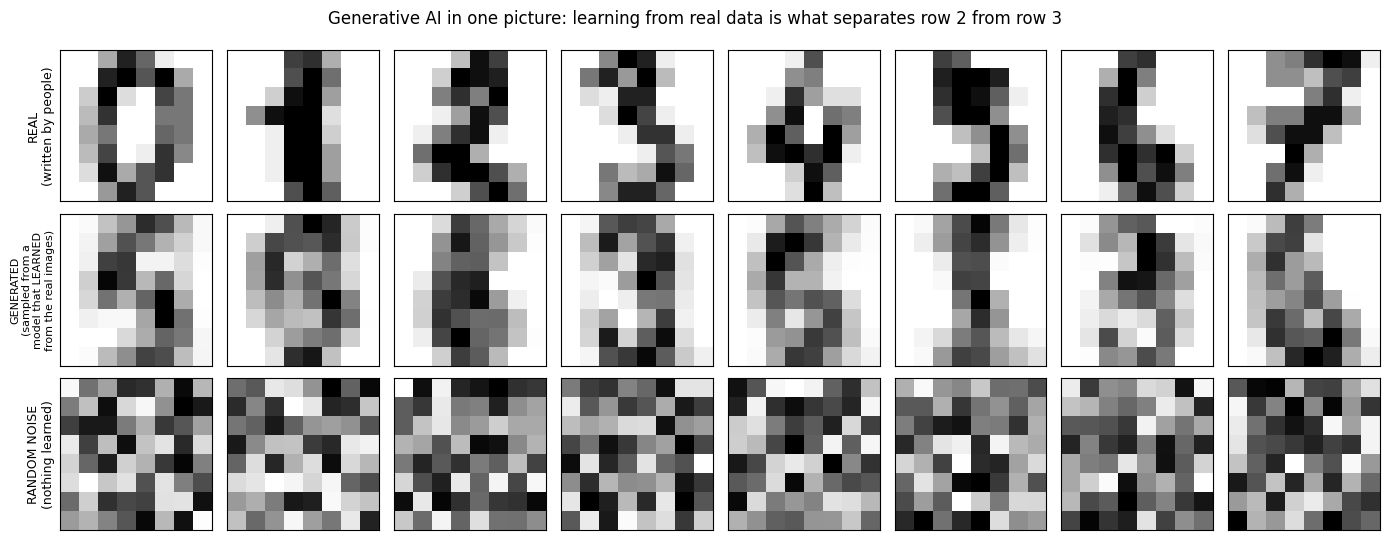


Distance to the nearest REAL digit (lower = more digit-like):
  Generated samples (model learned from data):  22.65
  Uniform random noise (nothing learned)     :  56.57

✅ Row 2 was produced by a model that LEARNED the shape of real handwriting
   and then sampled new examples from what it learned. That is the definition of
   generative AI at work — no one wrote a formula for the digit '3'.

⚠️  Honest caveat: PCA is a very weak generative model. Its samples are blurry
   averages, because it can only mix directions of variation linearly. Modern
   generative models (GANs, VAEs, diffusion) learn far richer distributions.
   You will train a GAN on real data in 04_simple_gan_experiment.ipynb.

5. Key Takeaways
1. Generative AI creates NEW content, not just predictions
2. Creating data is only 'generative AI' if the pattern was LEARNED from data — the PCA digit sampler above learned from 1,797 real handwritten images; the uniform-noise row learned nothing and looks like it
3. It learn

In [1]:
# What 'generative AI' means: the definition, ten years of evolution, the application
# landscape, and a first working generative model trained on REAL handwritten digits.
# This framing prepares you for the GAN experiment later in this unit.
"""
Unit 5 - Example 1: Introduction to Generative AI

This example demonstrates:
1. Understanding generative AI concepts
2. Historical evolution
3. Key applications
4. Real-world examples
"""

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

print("=" * 70)
print("Example 1: Introduction to Generative AI")
print("=" * 70)

# 1. What is Generative AI?
print("\n" + "=" * 70)
print("1. What is Generative AI?")
print("=" * 70)

# The working definition: systems that CREATE new content by learning patterns from data.
generative_ai_definition = """
Generative AI refers to artificial intelligence systems that can create new content, including text, images, audio, video, and other data types.

Key Characteristics:
- Creates NEW content (not just classification or prediction)
- Learns patterns from training data
- Generates novel outputs based on learned patterns
- Can produce diverse and creative outputs
"""

print(generative_ai_definition)

# 2. Evolution Timeline
print("\n" + "=" * 70)
print("2. Evolution of Generative AI")
print("=" * 70)

# A decade of breakthroughs: from GANs (2014) to multimodal models (2023).
timeline = {
    "2014": "GANs (Generative Adversarial Networks) introduced", "2015": "VAEs (Variational Autoencoders) become popular",
    "2017": "Transformer architecture revolutionizes NLP",
    "2019": "GPT-2 demonstrates impressive text generation",
    "2020": "GPT-3 shows few-shot learning capabilities",
    "2021": "DALL-E generates images from text",
    "2022": "ChatGPT and Stable Diffusion bring generative AI to mainstream",
    "2023": "GPT-4 and multimodal models advance the field"
}

for year, event in timeline.items():
    print(f"{year}: {event}")

# 3. Key Applications
print("\n" + "=" * 70)
print("3. Key Applications of Generative AI")
print("=" * 70)

# Five content types generative models can produce, each with concrete use cases.
applications = {
    "Text Generation": [
        "Creative writing", "Code generation",
        "Translation",
        "Summarization",
        "Chatbots and virtual assistants"
    ],
    "Image Generation": [
        "Art creation",
        "Product design",
        "Medical imaging",
        "Game assets",
        "Photo editing"
    ],
    "Audio Generation": [
        "Music composition",
        "Voice synthesis",
        "Sound effects",
        "Podcast generation"
    ],
    "Video Generation": [
        "Video editing",
        "Animation",
        "Virtual reality content",
        "Training simulations"
    ],
    "Data Generation": [
        "Synthetic datasets",
        "Data augmentation",
        "Privacy-preserving data",
        "Testing data"
    ]
}

for category, examples in applications.items():
    print(f"\n{category}:")
    for example in examples:
        print(f"  • {example}")

# 4. A first REAL generative model, trained on REAL handwritten digits
print("\n" + "=" * 70)
print("4. A First Generative Model, Learned From Real Handwritten Digits")
print("=" * 70)

# REAL DATA: 1,797 handwritten digit images collected from 43 people for the UCI
# "Optical Recognition of Handwritten Digits" study. Each image is 8x8 greyscale.
# Nobody invented these pixels — real hands wrote these digits.
digits = load_digits()
X_digits = digits.data          # shape (1797, 64): one row per image, 64 pixel values
print(f"\nReal dataset: UCI handwritten digits")
print(f"  {X_digits.shape[0]:,} real images, each {int(np.sqrt(X_digits.shape[1]))}x{int(np.sqrt(X_digits.shape[1]))} pixels")
print(f"  Written by 43 real people; pixel values run 0-16 (greyscale)")

# LEARN the distribution. PCA finds the 20 directions along which real digits actually
# vary, and tells us how much they vary along each one. That IS a learned model of
# "what a handwritten digit looks like" — we never wrote a formula for a digit.
N_COMPONENTS = 20
pca = PCA(n_components=N_COMPONENTS, random_state=42)
Z_real = pca.fit_transform(X_digits)     # real images projected into 20 learned dimensions
print(f"\n  Learned {N_COMPONENTS} components; they capture "
      f"{pca.explained_variance_ratio_.sum() * 100:.1f}% of the real variation in the images")

# GENERATE. We sample brand-new points from the distribution PCA LEARNED (each learned
# direction gets its own learned standard deviation), then decode them back into pixels.
# Randomness here IS the lesson: sampling is how a generative model produces novel output.
rng = np.random.default_rng(42)
learned_std = Z_real.std(axis=0)                       # learned spread per direction
Z_new = rng.normal(0.0, learned_std, size=(8, N_COMPONENTS))
X_generated = pca.inverse_transform(Z_new)             # decode latent samples into images

# A control condition: pure uniform noise over the same pixel range, with NO learning.
X_noise = rng.uniform(0, 16, size=(8, X_digits.shape[1]))

fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))
for j in range(8):
    axes[0, j].imshow(X_digits[j].reshape(8, 8), cmap="gray_r")
    axes[1, j].imshow(np.clip(X_generated[j], 0, 16).reshape(8, 8), cmap="gray_r")
    axes[2, j].imshow(X_noise[j].reshape(8, 8), cmap="gray_r")
    for row in range(3):
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([])
axes[0, 0].set_ylabel("REAL\n(written by people)", fontsize=9)
axes[1, 0].set_ylabel("GENERATED\n(sampled from a\nmodel that LEARNED\nfrom the real images)", fontsize=8)
axes[2, 0].set_ylabel("RANDOM NOISE\n(nothing learned)", fontsize=9)
fig.suptitle("Generative AI in one picture: learning from real data is what separates row 2 from row 3",
             fontsize=12)
plt.tight_layout()
plt.show()

# Measure the difference instead of just asserting it: how far is each row from the
# real data, measured by distance to the nearest real image in pixel space?
def mean_distance_to_nearest_real(batch):
    """Average Euclidean distance from each image in `batch` to its closest REAL digit."""
    d = np.linalg.norm(X_digits[None, :, :] - batch[:, None, :], axis=2)
    return d.min(axis=1).mean()

d_generated = mean_distance_to_nearest_real(np.clip(X_generated, 0, 16))
d_noise = mean_distance_to_nearest_real(X_noise)
print(f"\nDistance to the nearest REAL digit (lower = more digit-like):")
print(f"  Generated samples (model learned from data): {d_generated:6.2f}")
print(f"  Uniform random noise (nothing learned)     : {d_noise:6.2f}")

print("\n\u2705 Row 2 was produced by a model that LEARNED the shape of real handwriting")
print("   and then sampled new examples from what it learned. That is the definition of")
print("   generative AI at work \u2014 no one wrote a formula for the digit '3'.")
print("")
print("\u26a0\ufe0f  Honest caveat: PCA is a very weak generative model. Its samples are blurry")
print("   averages, because it can only mix directions of variation linearly. Modern")
print("   generative models (GANs, VAEs, diffusion) learn far richer distributions.")
print("   You will train a GAN on real data in 04_simple_gan_experiment.ipynb.")

# 5. Summary
print("\n" + "=" * 70)
print("5. Key Takeaways")
print("=" * 70)

takeaways = [
    "Generative AI creates NEW content, not just predictions",
    "Creating data is only 'generative AI' if the pattern was LEARNED from data — "
    "the PCA digit sampler above learned from 1,797 real handwritten images; "
    "the uniform-noise row learned nothing and looks like it",
    "It learns patterns from data and generates novel outputs",
    "Applications span text, images, audio, video, and data",
    "It's transforming industries from healthcare to entertainment",
    "Understanding generative AI is crucial for modern AI practitioners"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"{i}. {takeaway}")

print("\n" + "=" * 70)
print("Next: Learn about Generative vs Discriminative Models")
print("=" * 70)

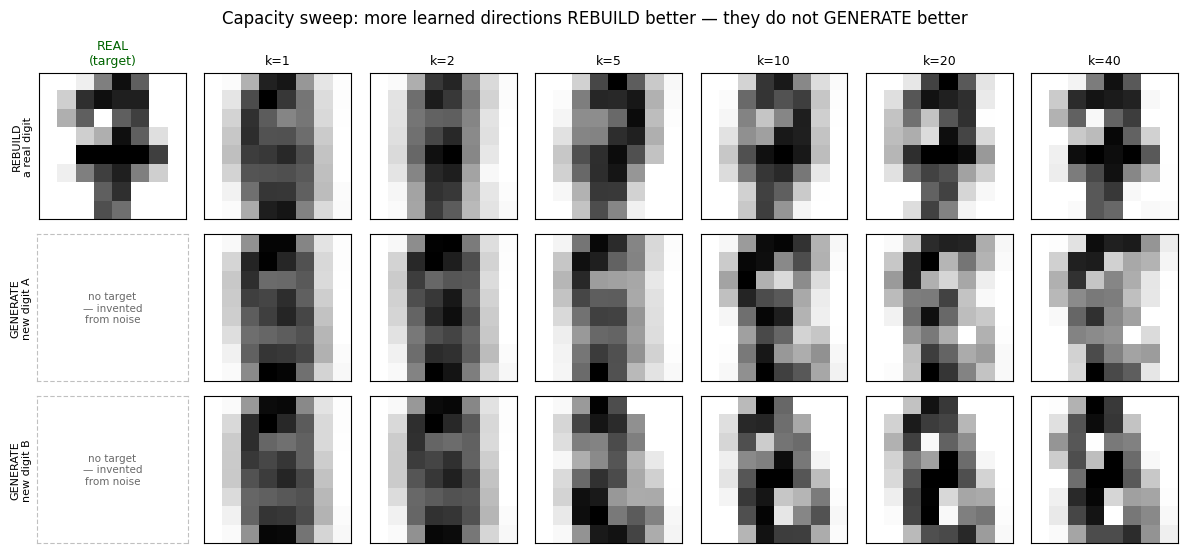

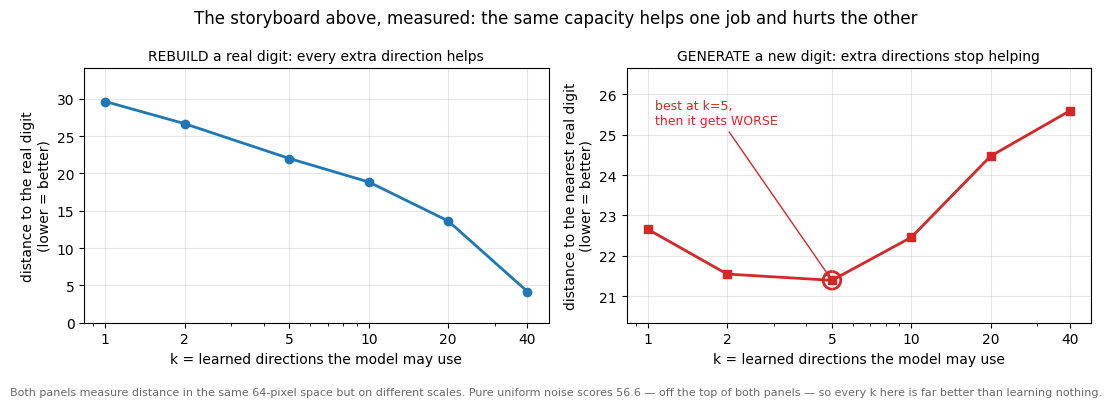

Step table for the storyboard above (all 1,797 real digits, 200 fresh samples per step):
step      k  variance kept  rebuild error  new-sample dist
   1      1          14.9%          29.64            22.66
   2      2          28.5%          26.67            21.55
   3      5          54.5%          22.00            21.39
   4     10          73.8%          18.85            22.46
   5     20          89.4%          13.64            24.47
   6     40          98.8%           4.17            25.60
      noise                                          56.57   <- learned nothing (row 3 of the first figure)

Rebuild error falls at EVERY step: 29.64 at k=1 -> 4.17 at k=40.
New-sample distance does NOT: it bottoms out at k=5 (21.39) and climbs back to 25.60 by k=40.
Copying real digits back and inventing convincing new ones are two different jobs,
and PCA is only good at the first one. That gap is why GANs and diffusion models exist.


In [2]:
# STEP STORYBOARD: what "20 components capture 89.4% of the variation" actually LOOKS like.
# WHAT: sweep the model's capacity k = 1, 2, 5, 10, 20, 40 and at every step render two jobs
# done by the SAME model, on the SAME real handwritten digits:
#   row 1 - REBUILD  : one real digit squeezed down to k numbers and decoded back to pixels
#   rows 2-3 - GENERATE : two brand-new digits, each the SAME point in latent space decoded
#                         with more and more capacity (nobody ever wrote these digits)
# WHY: a percentage on its own teaches nothing. Watching a real digit come back into focus
# makes "explained variance" something you can see — and the rebuild row and the generate
# rows do NOT improve together, which is the honest limit of PCA as a generative model.

K_STEPS = [1, 2, 5, 10, 20, 40]
DIGIT_IX = 17                            # one fixed real digit, rebuilt identically in every frame
rng_sweep = np.random.default_rng(7)     # sampling IS the lesson here, so seed it and move on
# Two fixed latent identities: the same standard-normal vector is reused at every k, so each
# column shows THE SAME imagined digit drawn with more of the directions the model learned.
u_fixed = rng_sweep.standard_normal((2, max(K_STEPS)))

fig, axes = plt.subplots(3, len(K_STEPS) + 1, figsize=(12, 5.6))

# Leftmost column: ONLY the rebuild row has a target. The two GENERATE rows are inventing
# digits from nothing, so there is no real digit they are aiming at — putting one beside them
# would imply a target that does not exist, and students would read the row as a failed copy.
axes[0, 0].imshow(X_digits[DIGIT_IX].reshape(8, 8), cmap="gray_r")
axes[0, 0].set_title("REAL\n(target)", fontsize=9, color="darkgreen")
for r in (1, 2):
    axes[r, 0].text(0.5, 0.5, "no target\n— invented\nfrom noise", ha="center", va="center",
                    fontsize=7.5, color="dimgray", transform=axes[r, 0].transAxes)
    for side in axes[r, 0].spines.values():
        side.set_linestyle((0, (3, 3)))
        side.set_color("silver")

sweep_rows = []
for col, k in enumerate(K_STEPS, start=1):
    pca_k = PCA(n_components=k, random_state=42)
    Z_k = pca_k.fit_transform(X_digits)                 # all 1,797 real digits, k learned directions
    learned_std_k = Z_k.std(axis=0)

    # REBUILD: keep only k numbers for our fixed real digit, then decode back to 64 pixels.
    x_rebuilt = pca_k.inverse_transform(Z_k[DIGIT_IX:DIGIT_IX + 1])[0]
    rebuild_err = float(np.linalg.norm(X_digits[DIGIT_IX] - x_rebuilt))

    # GENERATE: decode the two fixed latent identities, then measure a fresh batch of 200
    # samples so the printed number is a distribution statistic and not one lucky draw.
    X_ident = np.clip(pca_k.inverse_transform(u_fixed[:, :k] * learned_std_k), 0, 16)
    Z_batch = rng_sweep.normal(0.0, learned_std_k, size=(200, k))
    gen_dist = float(mean_distance_to_nearest_real(
        np.clip(pca_k.inverse_transform(Z_batch), 0, 16)))   # metric defined in the cell above

    axes[0, col].imshow(np.clip(x_rebuilt, 0, 16).reshape(8, 8), cmap="gray_r")
    axes[0, col].set_title(f"k={k}", fontsize=9)
    axes[1, col].imshow(X_ident[0].reshape(8, 8), cmap="gray_r")
    axes[2, col].imshow(X_ident[1].reshape(8, 8), cmap="gray_r")

    sweep_rows.append((k, pca_k.explained_variance_ratio_.sum() * 100, rebuild_err, gen_dist))

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("REBUILD\na real digit", fontsize=8)
axes[1, 0].set_ylabel("GENERATE\nnew digit A", fontsize=8)
axes[2, 0].set_ylabel("GENERATE\nnew digit B", fontsize=8)
fig.suptitle("Capacity sweep: more learned directions REBUILD better — they do not GENERATE better",
             fontsize=12)
plt.tight_layout()
plt.show()

# The same six steps as one measurement. Both quantities are distances in the SAME 64-pixel
# space (lower = better), but they live on very different scales, so they get one panel each —
# clipping either curve to fit the other would flatten the exact shape we are looking for.
ks = [r[0] for r in sweep_rows]
rebuild_err_by_k = [r[2] for r in sweep_rows]
gen_dist_by_k = [r[3] for r in sweep_rows]
best_ix = int(np.argmin(gen_dist_by_k))

fig2, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.0), sharex=True)

axL.plot(ks, rebuild_err_by_k, "o-", color="#1f77b4", linewidth=2)
axL.set_ylim(0, max(rebuild_err_by_k) * 1.15)
axL.set_title("REBUILD a real digit: every extra direction helps", fontsize=10)
axL.set_ylabel("distance to the real digit\n(lower = better)")

axR.plot(ks, gen_dist_by_k, "s-", color="#d62728", linewidth=2)
axR.scatter([ks[best_ix]], [gen_dist_by_k[best_ix]], s=160, facecolors="none",
            edgecolors="#d62728", linewidths=2)
axR.annotate(f"best at k={ks[best_ix]},\nthen it gets WORSE",
             xy=(ks[best_ix], gen_dist_by_k[best_ix]), xytext=(0.06, 0.88),
             textcoords="axes fraction", va="top", fontsize=9, color="#d62728",
             arrowprops=dict(arrowstyle="->", color="#d62728"))
span = max(gen_dist_by_k) - min(gen_dist_by_k)
axR.set_ylim(min(gen_dist_by_k) - 0.25 * span, max(gen_dist_by_k) + 0.25 * span)
axR.set_title("GENERATE a new digit: extra directions stop helping", fontsize=10)
axR.set_ylabel("distance to the nearest real digit\n(lower = better)")

for ax in (axL, axR):
    ax.set_xscale("log")
    ax.set_xticks(ks)
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_xlabel("k = learned directions the model may use")
    ax.grid(alpha=0.3)
fig2.suptitle("The storyboard above, measured: the same capacity helps one job and hurts the other",
              fontsize=12)
# Footnote rather than in-panel text, so nothing is written on top of a curve.
fig2.text(0.5, 0.015,
          f"Both panels measure distance in the same 64-pixel space but on different scales. "
          f"Pure uniform noise scores {d_noise:.1f} \u2014 off the top of both panels \u2014 so every k here is far "
          f"better than learning nothing.",
          ha="center", fontsize=8, color="dimgray")
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

# The step table behind the storyboard: every frame above, as numbers.
print("Step table for the storyboard above (all 1,797 real digits, 200 fresh samples per step):")
print(f"{'step':>4} {'k':>6} {'variance kept':>14} {'rebuild error':>14} {'new-sample dist':>16}")
for step, (k, evr, rerr, gdist) in enumerate(sweep_rows, start=1):
    print(f"{step:>4} {k:>6} {evr:13.1f}% {rerr:14.2f} {gdist:16.2f}")
print(f"{'':>4} {'noise':>6} {'':>14} {'':>14} {d_noise:16.2f}   <- learned nothing (row 3 of the first figure)")

best_k = min(sweep_rows, key=lambda r: r[3])[0]
print(f"\nRebuild error falls at EVERY step: {sweep_rows[0][2]:.2f} at k=1 -> {sweep_rows[-1][2]:.2f} at k={K_STEPS[-1]}.")
print(f"New-sample distance does NOT: it bottoms out at k={best_k} ({min(r[3] for r in sweep_rows):.2f}) "
      f"and climbs back to {sweep_rows[-1][3]:.2f} by k={K_STEPS[-1]}.")
print("Copying real digits back and inventing convincing new ones are two different jobs,")
print("and PCA is only good at the first one. That gap is why GANs and diffusion models exist.")

### 📊 Read the storyboard, then read its measurement

**Figure 1 — the storyboard, left to right.** Every frame is the same model — PCA on the same
1,797 real digits — given more capacity at each step.

- **Top row (REBUILD).** The `REAL (target)` frame on the left is one untouched handwritten digit,
  and it is the only frame in the figure with a target: at `k=1` the rebuild is a vertical smear
  with no identity at all, by `k=10` the strokes are reappearing, and at `k=20` and `k=40` the
  frame is close to the original. The step table measures it: rebuild error **29.64 → 4.17** as k
  goes 1 → 40, falling at every single step, alongside variance kept climbing **14.9% → 98.8%**.
  *That* is what "20 components capture 89.4% of the variation" means — not a statistic, a picture
  of a digit coming back into focus.
- **Bottom two rows (GENERATE).** These rows have **no target** — that is why their leftmost frame
  is empty instead of showing a real digit. Each column is the **same imagined digit**, one fixed
  point in latent space, decoded with more of the learned directions. Watch them and notice what
  does *not* happen: they change, they pick up texture and contrast, but they never lock onto a
  clean digit the way the top row does.

**Figure 2 — the same six steps as numbers.** Left panel: the rebuild curve falls at every
single step, 29.64 down to 4.17. Right panel: the generation curve does the opposite of
what you would expect — it dips to its best value at **k=5 (21.39)** and then climbs back to
**25.60** by k=40. Two curves, two shapes, one model. Note the panels have different y-scales,
because the two distances live on different ranges; the shapes are the message, not their heights.

**What this proves.** Rebuilding a digit you were given and inventing a convincing new one are two
different jobs, and capacity buys you the first without buying you the second. All six generated
frames still beat pure noise by a wide margin (**~21–26 against 56.57**), so learning from real
data is doing real work — it is just not enough work. Closing that gap is the entire reason GANs,
VAEs and diffusion models exist, and you train the first of them in
`04_simple_gan_experiment.ipynb`.


## 💬 Discuss

The cell above printed a decade of generative-AI history and then trained a first
generative model on real handwritten digits. Argue:

1. Air Canada's chatbot was fluent, helpful, and wrong. **Where in the system
   would you place the fix?** Options: better model, retrieval over the actual
   policy documents, a rule layer that refuses to answer fare questions, or a
   human in the loop. Pick one, cost it, and name what it fails to catch.
2. The evolution list runs 2014 GANs → 2015 VAEs → 2017 transformers → 2019 GPT-2
   → onward. **Pick the entry you think changed what people could *build*, as
   opposed to what researchers could publish**, and defend it against a classmate
   who picks another.
3. **Regional practice:** a Saudi government service wants a generative assistant
   for citizen enquiries about regulations. Write the three sentences you would
   put in the requirements document that would have prevented the Air Canada
   outcome. Then say what each sentence costs the project.


## ⚠️ Where this breaks

- **Fluency is optimised; truth is not.** A language model is trained to continue
  text plausibly. There is no term in that objective for "and be correct", which
  is why confident invention is the normal behaviour of the system rather than a
  malfunction of it. Any deployment that needs correctness has to supply it from
  outside the model.
- **A generator has no held-out accuracy.** For a classifier you count wrong
  labels. For open-ended generation there is no single right answer, so evaluation
  becomes human judgement or another model's judgement — both noisy, both
  expensive, and the second one demonstrably inconsistent. Whenever someone quotes
  a single quality number for a generative system, ask how it was produced.
- **Generative models memorise.** Trained on enough data they can reproduce
  training examples verbatim, including personal data and copyrighted text. The
  "privacy" and "intellectual property" rows in the ethics table are consequences
  of the training objective, not misuse of the product.
- **The application list ages fast; the failure modes do not.** Which model family
  is state of the art changes every year or two. Hallucination, memorisation,
  bias inherited from the training corpus, and the absence of a ground truth to
  check against have been constant since 2014 and are what you should design around.
- **When not to use a generative model at all:** when a correct answer exists and
  can be retrieved. Account balances, fare rules, dosage tables, legal deadlines —
  look them up. Generating them is strictly worse than a database query and
  strictly more liable, as *Moffatt v. Air Canada* established.


## 🔭 State of the field (2026)

The four-family map above — GANs, VAEs, transformers, diffusion — is the right way to *learn* this
subject and the wrong way to read a 2026 product page. Two things settled since it was written. First,
the live lineage for images, audio and video is not adversarial: latent diffusion moved generation
into a compressed latent space (Rombach et al., 2022), DiT replaced the U-Net with a transformer
(Peebles & Xie, 2022), and flow matching gave the same family a simulation-free training objective
that underlies today's few-step generators (Lipman et al., 2022). Second, understanding and generation
stopped being separate systems: the 2025–2026 mainstream is a single model that both interprets an
image and produces one, mapped by a dedicated survey (Zhao et al., 2025) and pushed further by 2026
architectures that use one discrete-diffusion mechanism for both jobs (Li et al., 2026).

What has *not* changed is the thing this notebook is actually about. A generator optimises
plausibility, not truth, so *Moffatt v. Air Canada* would have been decided the same way against any
2026 model — and the ethics, evaluation and deployment questions above transfer unchanged to whichever
family is winning when you graduate. Learn the families here; expect the ranking among them to keep
moving.

*Orientation only — the assessed content of this lesson is everything above this box.*

## 📚 References

1. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. <https://arxiv.org/abs/1406.2661>
2. Kingma, D. P., & Welling, M. (2014). *Auto-Encoding Variational Bayes*. ICLR. <https://arxiv.org/abs/1312.6114>
3. Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need* (Transformer). NeurIPS. <https://arxiv.org/abs/1706.03762>
4. Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. NeurIPS. <https://arxiv.org/abs/2006.11239>
5. Bommasani, R., Hudson, D. A., Adeli, E., et al. (2021). *On the Opportunities and Risks of Foundation Models*. arXiv. <https://arxiv.org/abs/2108.07258>
6. Rombach, R., Blattmann, A., Lorenz, D., et al. (2022). *High-Resolution Image Synthesis with Latent Diffusion Models* (Stable Diffusion). CVPR. <https://arxiv.org/abs/2112.10752>
7. Lipman, Y., Chen, R. T. Q., Ben-Hamu, H., et al. (2022). *Flow Matching for Generative Modeling*. arXiv. <https://arxiv.org/abs/2210.02747>
8. Zhao, S., Zhang, X., Guo, J., et al. (2025). *Unified Multimodal Understanding and Generation Models: Advances, Challenges, and Opportunities*. arXiv. <https://arxiv.org/abs/2505.02567>
9. Li, L., Long, Z., Shen, Y., et al. (2026). *Omni-Diffusion: Unified Multimodal Understanding and Generation with Masked Discrete Diffusion*. arXiv. <https://arxiv.org/abs/2603.06577>
10. Peebles, W., & Xie, S. (2022). *Scalable Diffusion Models with Transformers* (DiT). arXiv. <https://arxiv.org/abs/2212.09748>